In [2]:
%pip install -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [5]:

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
import hdbscan


import matplotlib.pyplot as plt
import umap

import networkx as nx
from matplotlib import cm
import numpy as np



# Pipeline di parsing, embedding e preparazione grafi

Il seguente codice implementa una pipeline per l’analisi di sottografi estratti da file testuali strutturati.

### 1. Parsing dei sottografi da file TXT

La funzione `parse_subgraph(filepath)` legge un file di testo contenente più sottografi e li converte in una lista di grafi diretti di NetworkX.

Il formato atteso del file è:

- `S` → indica l’inizio di un nuovo sottografo  
- `v ID LABEL` → definisce un nodo con identificatore e attività associata  
- `d SOURCE TARGET LABEL` oppure `e SOURCE TARGET LABEL` → definisce un arco diretto

Durante il parsing:

- Se un arco fa riferimento a un nodo non ancora definito, il nodo viene creato automaticamente con label `"UNK"`.
- L’ultimo grafo del file viene salvato dopo la lettura completa.

Output della funzione:
- Lista di grafi diretti (`networkx.DiGraph`).

---

### 2. Sanitizzazione dei grafi

La funzione `sanitize_graph(g)` garantisce la consistenza strutturale del grafo prima dell’analisi.

Operazioni effettuate:

- Conversione del grafo in grafo non diretto.
- Rimozione dei nodi privi di attributo `label`.

Questa fase è necessaria per evitare errori nelle successive fasi di embedding.

---

### 3. Feature-based Graph Embedding strutturale

La funzione `graph_embedding_features(graphs)` trasforma ogni grafo in un vettore numerico di 6 feature strutturali:

Le feature estratte sono:

- Numero di nodi  
- Numero di archi  
- Densità del grafo  
- Degree medio dei nodi  
- Numero di componenti connesse  
- Lunghezza media dei cammini (se il grafo è connesso)

Se il grafo è vuoto o non valido, viene ignorato.

Output della funzione:
- Matrice di embedding strutturale con dimensione:

\[
N_{graphs} \times 6
\]

---

### 4. Pipeline principale

La pipeline esegue le seguenti operazioni:

1. Lettura dei sottografi anomali e corretti dai file TXT.
2. Costruzione delle liste di grafi NetworkX.
3. Unione dei grafi in un unico dataset.
4. Estrazione dell’embedding strutturale.

Output finale:

- `X_embedding`: matrice numerica utilizzabile per clustering o analisi statistica.
- Shape della matrice stampata a video.

---


In [6]:

# ==========================================================
# PARSER TXT → LISTA DI GRAFI
# ==========================================================

def parse_subgraph(filepath):

    graphs = []
    G = None

    with open(filepath, 'r') as f:

        for line in f:

            line = line.strip()
            if not line:
                continue

            # Inizio nuovo sottografo
            if line == 'S':

                if G is not None and len(G.nodes) > 0:
                    graphs.append(G)

                G = nx.DiGraph()
                continue

            # Nodo
            if line.startswith('v '):

                if G is None:
                    continue

                parts = line.split(maxsplit=2)

                if len(parts) >= 3:
                    node_id = parts[1]
                    label = parts[2]

                    G.add_node(node_id, label=str(label))

            # Arco
            elif line.startswith('d ') or line.startswith('e '):

                if G is None:
                    continue

                parts = line.split(maxsplit=3)

                if len(parts) >= 4:
                    source = parts[1]
                    target = parts[2]
                    label = parts[3]

                    # Assicura che i nodi esistano
                    if source not in G.nodes:
                        G.add_node(source, label="UNK")

                    if target not in G.nodes:
                        G.add_node(target, label="UNK")

                    G.add_edge(source, target, label=str(label))

    # Ultimo grafo
    if G is not None and len(G.nodes) > 0:
        graphs.append(G)

    return graphs


# ==========================================================
# SANITIZATION GRAFI
# ==========================================================

def sanitize_graph(g):

    g = nx.Graph(g)

    # Rimuovi nodi senza label
    nodes_to_remove = []

    for n in g.nodes():
        if 'label' not in g.nodes[n]:
            nodes_to_remove.append(n)

    g.remove_nodes_from(nodes_to_remove)

    return g


# ==========================================================
# GRAPH EMBEDDING STRUCTURAL FEATURES
# ==========================================================

def graph_embedding_features(graphs):

    embeddings = []

    for g in graphs:

        if len(g.nodes()) == 0:
            continue

        g = sanitize_graph(g)

        num_nodes = len(g.nodes())
        num_edges = len(g.edges())

        density = nx.density(g)

        degrees = [d for _, d in g.degree()]
        avg_degree = np.mean(degrees) if len(degrees) > 0 else 0

        # Connected components
        try:
            scc = nx.number_connected_components(g)
        except:
            scc = 0

        # Path length
        try:
            if len(g.nodes()) > 1 and nx.is_connected(g):
                avg_path_length = nx.average_shortest_path_length(g)
            else:
                avg_path_length = 0
        except:
            avg_path_length = 0

        embeddings.append([
            num_nodes,
            num_edges,
            density,
            avg_degree,
            scc,
            avg_path_length
        ])

    return np.array(embeddings)


# ==========================================================
# MAIN PIPELINE
# ==========================================================

# Path dataset
anomalous_path = "../../datasets/custom/anomalous_sub.txt"
correct_path = "../../datasets/custom/correct_sub.txt"

# Parsing
anomalous_graphs = parse_subgraph(anomalous_path)
correct_graphs = parse_subgraph(correct_path)

print("Anomalous graphs:", len(anomalous_graphs))
print("Correct graphs:", len(correct_graphs))

# Embedding
all_graphs = anomalous_graphs + correct_graphs

X_embedding = graph_embedding_features(all_graphs)

print("Embedding matrix shape:", X_embedding.shape)

Anomalous graphs: 27
Correct graphs: 140
Embedding matrix shape: (167, 6)


# Clustering dei sottografi tramite HDBSCAN

Questa sezione della pipeline applica una fase di clustering non supervisionato sull’embedding strutturale dei grafi.

### 1. Standardizzazione dell’embedding

Prima del clustering, le feature vengono normalizzate utilizzando `StandardScaler`.

La standardizzazione è necessaria perché le feature estratte hanno scale differenti. Senza questa fase, le feature con valori numerici più grandi potrebbero dominare il processo di clustering.

La trasformazione applicata è:

\[
X_{scaled} = \frac{X - \mu}{\sigma}
\]

dove:
- \( \mu \) è la media della feature
- \( \sigma \) è la deviazione standard

---

### 2. Clustering con HDBSCAN

Viene utilizzato l’algoritmo:

**HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)**

Configurazione utilizzata:

- `min_cluster_size = 5`
  → definisce la dimensione minima di un cluster stabile.

- `min_samples = 3`
  → controlla la sensibilità nella definizione delle regioni dense.

- `metric = 'euclidean'`
  → distanza utilizzata nello spazio embedding.

---

### 3. Output del clustering

L’algoritmo restituisce un vettore di etichette:

- Valori ≥ 0 → identificano cluster strutturali dei sottografi.
- Valore -1 → indica punti considerati rumore o outlier.

Il numero totale di cluster individuati viene calcolato come:

\[
N_{clusters} = |\text{unique labels}| - 1 \quad (\text{se esiste il noise cluster})
\]

---

### 4. Scopo della fase di clustering

Il clustering permette di:

- Raggruppare sottografi con struttura di processo simile.
- Identificare pattern ricorrenti nei comportamenti anomali e normali.
- Supportare l’analisi interpretativa delle varianti di processo.

Questa fase è fondamentale per la scoperta di modelli locali emergenti nel log di eventi.

In [7]:
# ===============================
# STANDARDIZZAZIONE EMBEDDING
# ===============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_embedding)

# ===============================
# HDBSCAN CLUSTERING
# ===============================

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=3,
    metric='euclidean'
)

labels = clusterer.fit_predict(X_scaled)

print("Cluster labels:", labels)
print("Numero cluster trovati:", len(set(labels)) - (1 if -1 in labels else 0))


print("Numero grafi:", X_embedding.shape[0])
print("Dimensione embedding:", X_embedding.shape[1])
print("Noise points:", np.sum(labels == -1))

Cluster labels: [ 2  7  2  3  2  0  2  4  3  6  0  1  3  6  8  1  0  7  3  6  5  5  8  8
  2  3  5  4  7  7  2  3  8  4  8  8  8  0  8  3  1  0  7  8  1  2  7  4
  5  8  2  3  1  4  0  2  7  4  6  8  1  5  0  3  3  8  8  8  8  5  7  5
  6  7  8  1  8  5  3  5  0  3  8  4  8  4  3  7  6  8  7  7  4  5  6  8
  8  7  5  6  7  8  8  1  6  3  1  5  3  2  4  0  2  1  3  0  7  5  2  5
  8  5  3  6  5  8  5  6  4  4  7  8  5  7  5  6  3  7  5  5  7  4  7 -1
 -1  6  5  5  6  8  6  7  8  4  8  1  5  7  8  4  1  3  8  5  1  2  3]
Numero cluster trovati: 9
Numero grafi: 167
Dimensione embedding: 6
Noise points: 2


# Visualizzazione dei cluster tramite UMAP

Questa sezione della pipeline consente di visualizzare i risultati del clustering ottenuto con HDBSCAN riducendo la dimensionalità dello spazio embedding.

Poiché l’embedding dei grafi ha dimensione 6, viene applicata una tecnica di riduzione dimensionale non lineare per rappresentare i dati in 2D.

---

### 1. Riduzione dimensionale con UMAP

Viene utilizzato **Uniform Manifold Approximation and Projection (UMAP)** per proiettare i dati dallo spazio ad alta dimensione allo spazio bidimensionale.

Configurazione utilizzata:

- `n_neighbors = 15`  
  → controlla il livello di preservazione della struttura locale del dataset.

- `min_dist = 0.1`  
  → regola la compattezza dei cluster nella rappresentazione visuale.

- `metric = 'euclidean'`  
  → distanza utilizzata nello spazio embedding normalizzato.

UMAP è particolarmente adatto perché preserva la struttura topologica locale dei dati, rendendo visivamente separabili i cluster trovati.

---

### 2. Visualizzazione dei cluster

I punti proiettati nello spazio 2D sono colorati in base all’etichetta di clustering ottenuta da HDBSCAN.

- Cluster con label ≥ 0 → rappresentano pattern strutturali ricorrenti dei sottografi.
- Label = -1 → rappresentano outlier o comportamenti non densamente supportati (rumore).

Ogni cluster è rappresentato con un marker differente:

- `o` → punti appartenenti a cluster strutturali
- `x` → punti classificati come rumore

---

### 3. Scopo della visualizzazione

La rappresentazione grafica permette di:

- Verificare qualitativamente la separazione dei cluster.
- Identificare eventuali regioni di sovrapposizione.
- Analizzare la distribuzione spaziale delle varianti di processo.

Questa fase supporta l’interpretazione dei pattern scoperti nella fase di clustering.

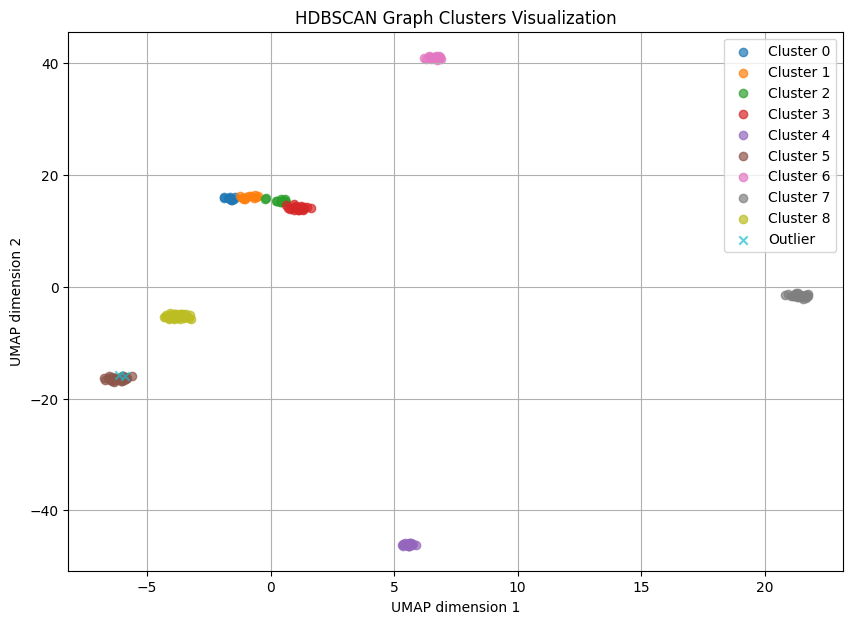

In [8]:
# ===============================
# RIDUZIONE DIMENSIONALE
# ===============================

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.2,
    metric='euclidean'
)

X_2d = reducer.fit_transform(X_scaled)

# ===============================
# PLOT CLUSTER
# ===============================

plt.figure(figsize=(10, 7))

unique_labels = set(labels)

for cluster_id in unique_labels:

    mask = labels == cluster_id

    if cluster_id == -1:
        # outlier
        label_name = "Outlier"
        marker_style = 'x'
    else:
        label_name = f"Cluster {cluster_id}"
        marker_style = 'o'

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=label_name,
        alpha=0.7,
        marker=marker_style
    )

plt.legend()
plt.title("HDBSCAN Graph Clusters Visualization")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.grid(True)

plt.show()

In [9]:
import pandas as pd
n_anomalous = len(anomalous_graphs)

labels_all = labels

df_cluster = pd.DataFrame({
    "cluster": labels_all,
    "type": ["anomalous"] * len(anomalous_graphs) +
            ["correct"] * len(correct_graphs)
})

print(df_cluster.groupby(["cluster", "type"]).size())

cluster  type     
-1       correct       2
 0       anomalous     3
         correct       7
 1       anomalous     2
         correct      11
 2       anomalous     5
         correct       8
 3       anomalous     5
         correct      15
 4       anomalous     1
         correct      14
 5       anomalous     3
         correct      22
 6       anomalous     3
         correct      12
 7       anomalous     2
         correct      20
 8       anomalous     3
         correct      29
dtype: int64


# Valutazione della purezza dei cluster (Cluster Purity)

Questa sezione misura la qualità del clustering confrontando le etichette ottenute dall’algoritmo non supervisionato con le classi reali disponibili.

Poiché il problema è di tipo anomaly discovery, vengono utilizzate le etichette ground truth:

- `"anomalous"`  
- `"correct"`

---

### 1. Costruzione delle etichette vere

Viene creato il vettore:

\[
y_{true} =
\begin{cases}
anomalous & \text{se il grafo è anomalo} \\
correct & \text{se il grafo è normale}
\end{cases}
\]

Le etichette sono concatenate mantenendo l’ordine dei grafi nella lista embedding.

---

### 2. Struttura del DataFrame di valutazione

Viene costruito un dataframe con due colonne:

- `cluster` → etichetta assegnata da HDBSCAN  
- `true` → classe reale del sottografo

Questo permette di confrontare clustering non supervisionato e ground truth supervisionata.

---

### 3. Calcolo della purity del cluster

La purity misura quanto un cluster contiene elementi della stessa classe.

Per ogni cluster (escludendo il rumore, label = -1):

1. Si seleziona il sottoinsieme dei grafi appartenenti al cluster.
2. Si identifica la classe maggioritaria nel cluster.
3. La purity è calcolata come:

\[
Purity(C) = \frac{\max_{class} |C_{majority}|}{|C|}
\]

Dove:
- \( |C_{majority}| \) è il numero di elementi della classe più frequente nel cluster.
- \( |C| \) è la dimensione totale del cluster.

---

### 4. Interpretazione del risultato

- Purity vicino a 1 → cluster molto omogeneo.
- Purity bassa → cluster misto o poco separabile.

Questa metrica permette di valutare la qualità del raggruppamento dei sottografi rispetto alla verità nota.

---

### 5. Scopo dell’analisi

Questa fase serve a verificare se lo spazio embedding e l’algoritmo di clustering sono adeguati a separare:

- Varianti di processo normali  
- Comportamenti anomali strutturalmente diversi

In [10]:

# costruisci label vere
true_labels = np.array(
    ["anomalous"] * len(anomalous_graphs) +
    ["correct"] * len(correct_graphs)
)

df_eval = pd.DataFrame({
    "cluster": labels,
    "true": true_labels
})

purity_dict = {}

for cluster_id in set(labels):
    if cluster_id == -1:
        continue

    subset = df_eval[df_eval["cluster"] == cluster_id]

    if len(subset) == 0:
        continue

    majority_class = subset["true"].value_counts().max()

    purity_dict[cluster_id] = majority_class / len(subset)

print(purity_dict)

{0: 0.7, 1: 0.8461538461538461, 2: 0.6153846153846154, 3: 0.75, 4: 0.9333333333333333, 5: 0.88, 6: 0.8, 7: 0.9090909090909091, 8: 0.90625}


I risultati indicano una buona separazione complessiva dei cluster. La purity varia tra circa 0.61 e 0.93.

I cluster 4, 7 e 8 mostrano la qualità migliore, con purity superiore a 0.90, suggerendo che contengono pattern molto omogenei e ben separati nello spazio embedding.

I cluster 2 e 0 presentano la qualità relativamente più bassa (0.61 e 0.70), indicando maggiore eterogeneità interna o possibile sovrapposizione tra sottografi normali e anomali.

In media, la purity dei cluster è elevata, quindi la pipeline embedding + clustering sembra adeguata per discriminare le varianti di processo nei dati analizzati.


# Estrazione dei prototipi rappresentativi dei cluster (Medoid Graphs)

Questa funzione consente di identificare il **grafo prototipo** di ogni cluster ottenuto tramite HDBSCAN.

Il prototipo è definito come il **medoid del cluster**, cioè il grafo che minimizza la distanza media rispetto agli altri grafi appartenenti allo stesso cluster nello spazio embedding.

---

### 1. Definizione del prototipo di cluster

Per ogni cluster (escludendo il cluster di rumore etichettato con -1):

1. Vengono individuati gli indici dei grafi appartenenti al cluster.
2. Si estraggono i corrispondenti vettori embedding.
3. Si calcola la matrice di distanza pairwise all’interno del cluster.

La distanza utilizzata è:

\[
D_{ij} = ||x_i - x_j||_2
\]

ottenuta tramite distanza euclidea nello spazio embedding standardizzato.

---

### 2. Selezione del medoid

Il grafo prototipo viene scelto come:

\[
g^* = \arg\min_{g_i \in C} \frac{1}{|C|} \sum_{j \in C} d(g_i, g_j)
\]

dove:

- \( C \) è l’insieme dei grafi del cluster.
- \( d(\cdot,\cdot) \) è la distanza euclidea.
- Il medoid rappresenta il grafo più centrale e stabile del cluster.

---

### 3. Costruzione del dizionario dei prototipi

Il risultato finale è un dizionario:


In [11]:
from sklearn.metrics import pairwise_distances

def extract_cluster_prototypes(graphs, embeddings, labels):

    prototypes = {}

    unique_clusters = set(labels)

    # Converti embeddings in numpy array (solo embedding!)
    embeddings = np.array(embeddings)

    for cluster_id in unique_clusters:

        if cluster_id == -1:
            continue

        cluster_indices = np.where(labels == cluster_id)[0]

        if len(cluster_indices) == 0:
            continue

        cluster_embeddings = embeddings[cluster_indices]

        # distanza pairwise dentro cluster
        dist_matrix = pairwise_distances(cluster_embeddings)

        medoid_local_idx = np.argmin(dist_matrix.mean(axis=1))

        prototype_global_index = cluster_indices[medoid_local_idx]

        prototypes[cluster_id] = graphs[prototype_global_index]

    return prototypes

# ===============================
# Estrai prototipi
# ===============================

all_graphs = anomalous_graphs + correct_graphs

prototypes = extract_cluster_prototypes(
    all_graphs,
    X_scaled,
    labels
)

print("Prototipi estratti per cluster:", prototypes.keys())

Prototipi estratti per cluster: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8])


# Calcolo dello score di anomalia dei prototipi di cluster

Questa funzione valuta il livello di anomalia di un grafo prototipo confrontandolo con due riferimenti globali: il comportamento di processo normale e il comportamento anomalo globale.

---

### 1. Rappresentazione embedding dei grafi

Ogni grafo viene trasformato in un vettore numerico tramite una funzione di embedding strutturale.

Le feature del grafo vengono estratte mediante:

- Numero di nodi  
- Numero di archi  
- Densità del grafo  
- Degree medio  
- Numero di componenti connesse  
- Lunghezza media dei cammini

Successivamente, le feature vengono normalizzate utilizzando uno scaler statistico per garantire coerenza nello spazio metrico.

La trasformazione consente di confrontare grafi diversi utilizzando distanza euclidea nello spazio embedding.

---

### 2. Calcolo delle distanze verso i prototipi globali

Per ogni cluster prototype vengono calcolate due distanze principali:

- \( d_{norm} \): distanza dal prototipo del processo normale globale  
- \( d_{anom} \): distanza dal prototipo del comportamento anomalo globale  

Le distanze sono calcolate tramite distanza pairwise nello spazio vettoriale:

\[
d(x,y) = ||x - y||_2
\]

---

### 3. Definizione dello score di anomalia

Lo score di anomalia è definito come:

\[
Score = \frac{d_{anom}}{d_{anom} + d_{norm} + \epsilon}
\]

dove:

- \( \epsilon \) è un termine di stabilizzazione numerica.

---

### 4. Interpretazione dello score

Lo score assume valori nell’intervallo \([0,1]\):

- Score vicino a 1 → il prototype è più simile al comportamento normale.
- Score vicino a 0 → il prototype è più simile al comportamento anomalo.
- Score intorno a 0.5 → zona ambigua o comportamento misto.

---

### 5. Scopo dell’analisi

Questa metrica consente di:

- Valutare la natura strutturale dei cluster di sottografi.
- Supportare decisioni interpretative sulle varianti di processo.
- Distinguere varianti legittime da deviazioni anomale.

In [12]:
def compute_prototype_anomaly_score(
        prototype_graph,
        normal_prototype_graph,
        anomaly_prototype_graph,
        embedding_func,
        scaler):

    # ===============================
    # Embed prototype graphs
    # ===============================

    def graph_to_embedding(g):
        feat = graph_embedding_features([g])
        feat_scaled = scaler.transform(feat)
        return feat_scaled[0]

    proto_vec = graph_to_embedding(prototype_graph)

    normal_vec = graph_to_embedding(normal_prototype_graph)
    anomaly_vec = graph_to_embedding(anomaly_prototype_graph)

    # ===============================
    # Distance computation
    # ===============================

    d_norm = pairwise_distances(
        [proto_vec],
        [normal_vec]
    )[0][0]

    d_anom = pairwise_distances(
        [proto_vec],
        [anomaly_vec]
    )[0][0]

    # ===============================
    # Anomaly score
    # ===============================

    score = d_anom / (d_anom + d_norm + 1e-8)

    return score, d_norm, d_anom

# Valutazione di anomalia dei prototipi dei cluster

Questa sezione della pipeline calcola un indice di anomalia per ciascun grafo prototipo dei cluster scoperti tramite HDBSCAN.

L’obiettivo è determinare se il comportamento rappresentato da un cluster è più vicino al processo normativo oppure al comportamento anomalo globale.

---

### 1. Costruzione dei prototipi globali di riferimento

Vengono estratti due prototipi globali utilizzando il criterio del medoid:

- **Prototipo del processo normale globale**, ottenuto dai grafi classificati come `"correct"`.
- **Prototipo del comportamento anomalo globale**, ottenuto dai grafi classificati come `"anomalous"`.

Il prototipo viene selezionato come il grafo che minimizza la distanza media verso gli altri grafi del gruppo nello spazio embedding.

---

### 2. Standardizzazione dello spazio embedding

Prima del confronto, le feature strutturali dei grafi vengono trasformate tramite:

- embedding numerico
- normalizzazione statistica con scaler

Questo garantisce comparabilità metrica tra grafi diversi.

---

### 3. Calcolo dello score di anomalia dei cluster

Per ogni cluster prototype viene calcolato un indice di rischio strutturale definito come:

\[
Score = \frac{d_{anom}}{d_{anom} + d_{norm} + \epsilon}
\]

dove:

- \( d_{norm} \) = distanza dal prototipo del processo normale globale  
- \( d_{anom} \) = distanza dal prototipo del comportamento anomalo globale  
- \( \epsilon \) = termine di stabilizzazione numerica




In [13]:
normal_global_prototype = extract_cluster_prototypes(
    correct_graphs,
    scaler.transform(graph_embedding_features(correct_graphs)),
    np.zeros(len(correct_graphs))
).get(0)

anomaly_global_prototype = extract_cluster_prototypes(
    anomalous_graphs,
    scaler.transform(graph_embedding_features(anomalous_graphs)),
    np.zeros(len(anomalous_graphs))
).get(0)

scores = {}

for cluster_id, proto_graph in prototypes.items():

    score, d_norm, d_anom = compute_prototype_anomaly_score(
        proto_graph,
        normal_global_prototype,
        anomaly_global_prototype,
        graph_embedding_features,
        scaler
    )

    scores[cluster_id] = score

print(scores)

{0: 0.41342212461804284, 1: 0.34119789158590696, 2: 0.23257785842142992, 3: 0.0, 4: 0.35862542313047163, 5: 0.7239614668521551, 6: 0.6859158163908525, 7: 0.9999999954051775, 8: 0.8090703580150694}


Notiamo che i prototipi dei cluster 5,6,7 e 8 superano abbondandemente il 0.5, quindi potrebbero essere rappresentativi di comportamenti anomali generalizzati.

# Visualizzazione dei prototipi dei cluster con scala di anomalia

Questa funzione consente di visualizzare i grafo-prototipi dei cluster scoperti nella pipeline di analisi.

L’obiettivo è rappresentare contemporaneamente:

- La struttura topologica del prototipo di ciascun cluster.
- Il livello di anomalia associato al cluster tramite una scala colore continua.

---

### 1. Organizzazione della griglia di visualizzazione

I prototipi vengono disposti in una griglia con un numero fissato di colonne.

Il numero di righe viene calcolato automaticamente:

\[
rows = \lceil \frac{N_{prototypes}}{columns} \rceil
\]

Questo permette di adattare dinamicamente la figura al numero di cluster presenti.

---

### 2. Mappatura dello score di anomalia al colore

La colorazione dei nodi dei grafi prototipo è basata sulla colormap **viridis**, che mappa lo score di anomalia nell’intervallo \([0,1]\).

Lo score è definito come:

\[
Score = \frac{d_{anom}}{d_{anom}+d_{norm}+\epsilon}
\]

dove:

- valori vicini a 1 indicano comportamento più normativo,
- valori vicini a 0 indicano maggiore somiglianza al comportamento anomalo.

---

### 3. Layout grafico dei sottografi

La disposizione dei nodi all’interno di ciascun grafo è ottenuta tramite:

- algoritmo `spring_layout` di NetworkX.

Questo layout simula un sistema fisico di molle, ottimizzando la separazione tra nodi collegati.

---

### 4. Colorbar interpretativa globale

Una barra colore laterale viene aggiunta alla figura per fornire una legenda continua dello score di anomalia.

Configurazione della colorbar:

- Range fissato in \([0,1]\).
- Etichetta esplicativa: **"Anomaly Score"**.

La colorbar è posizionata esternamente alla griglia per evitare sovrapposizioni con i grafi.

---

### 5. Scopo della visualizzazione

Questa rappresentazione supporta:

- Interpretabilità dei cluster di sottografi.
- Analisi qualitativa delle varianti di processo.
- Valutazione visiva del rischio di anomalia strutturale.

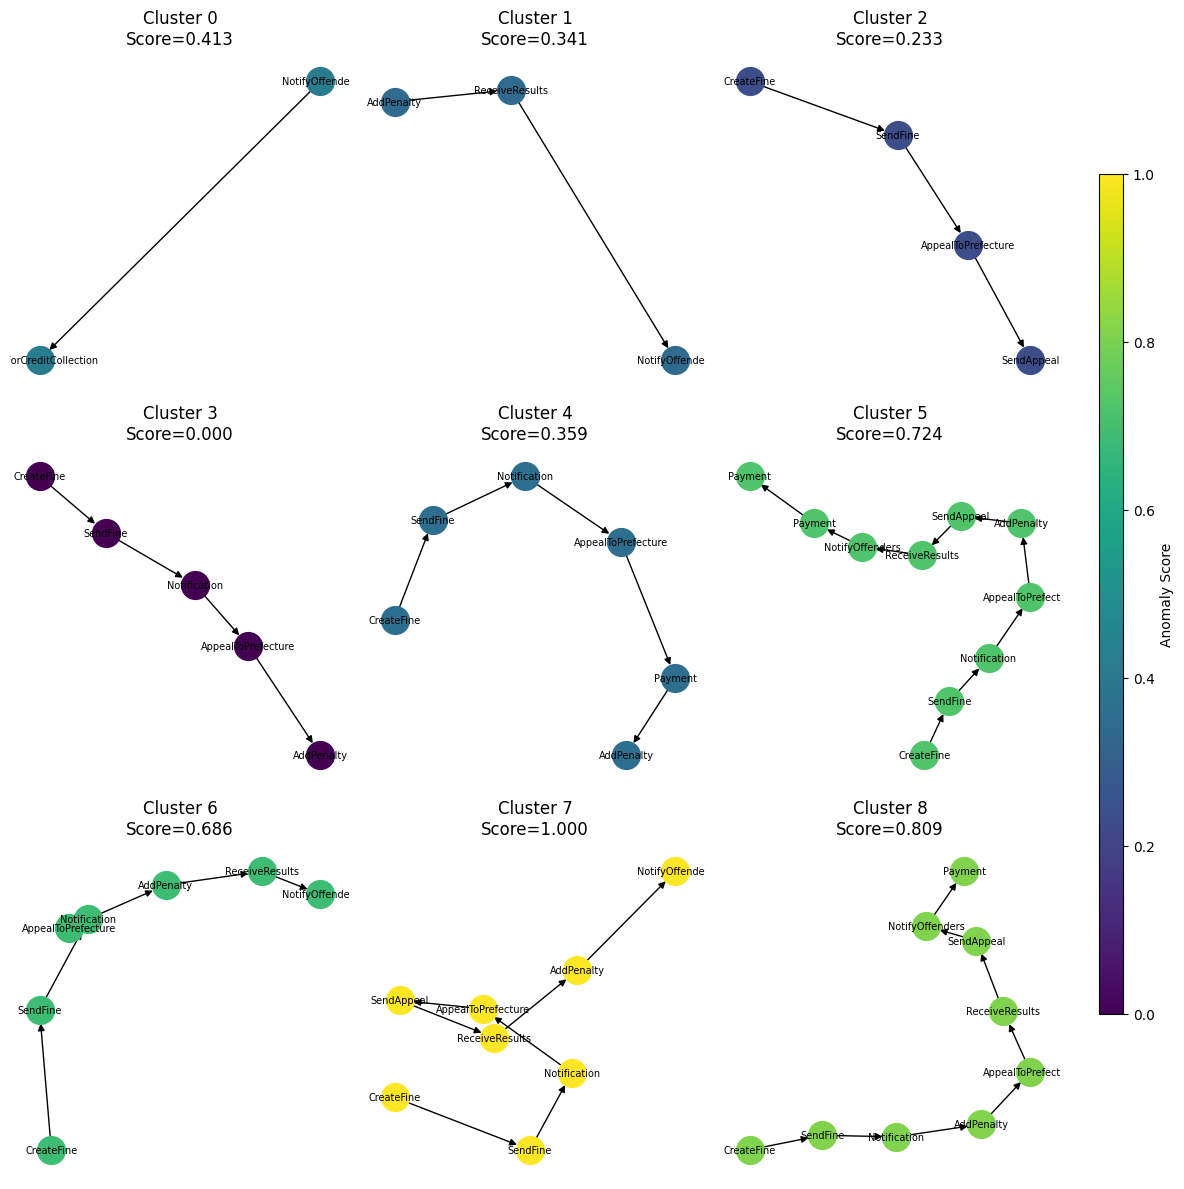

In [14]:

def plot_prototypes_grid(prototypes, scores, cols=3):

    n = len(prototypes)
    rows = int(np.ceil(n / cols))

    colormap = cm.get_cmap("viridis")

    fig = plt.figure(figsize=(4 * cols, 4 * rows))

    # ===============================
    # Plot grafi
    # ===============================

    for idx, (cluster_id, G_proto) in enumerate(prototypes.items()):

        score = scores.get(cluster_id, 0.0)

        color = colormap(score)

        ax = plt.subplot(rows, cols, idx + 1)

        pos = nx.spring_layout(G_proto)

        labels = nx.get_node_attributes(G_proto, 'label')

        nx.draw(
            G_proto,
            pos,
            node_color=[color],
            with_labels=True,
            labels=labels,
            node_size=400,
            font_size=7,
            ax=ax
        )

        plt.title(f"Cluster {cluster_id}\nScore={score:.3f}")

    # ===============================
    # Colorbar laterale globale
    # ===============================
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

    sm = plt.cm.ScalarMappable(
        cmap=colormap,
        norm=plt.Normalize(vmin=0, vmax=1)
    )

    sm.set_array([])

    fig.colorbar(sm, cax=cbar_ax, label="Anomaly Score")

    plt.subplots_adjust(right=0.9)
    plt.tight_layout(rect=[0, 0, 0.9, 1])

    plt.show()


# ===============================
# Plot grid prototypes
# ===============================

plot_prototypes_grid(prototypes, scores)